# MDD / A/B-анализ latency для архитектурного решения

Этот ноутбук является расчётным артефактом для **ADR-0003: принятие архитектурного решения на основе анализа latency**.

Цель ноутбука показать применение подхода **Metrics Driven Development (MDD)**, то есть что архитектурное решение принимается на основе статистического сравнения двух вариантов системы.

В рамках проекта основная ML-задача решается на датасете **AI4I 2020 Predictive Maintenance Dataset**.  
Отдельно для шага 5 задания анализируется **техническая метрика latency** prediction service.

Сравниваются два варианта системы, заданные в условии шага 5:

- **A / existing system** — существующая система из условия задания;
- **B / improved system** — улучшенная система из условия задания.

Целевая метрика:

```text
latency, seconds
```

Эти значения не являются фактическими latency-логами уже развернутого проекта. Они используются как предоставленные в задании данные для демонстрации MDD-подхода.


## 1. Условия шага 5

В условии шага 5 дан код, который задаёт два набора latency-метрик:

```python
existing_system_responses = np.random.normal(loc=3.5, scale=0.4, size=500000)
improved_system_responses = np.random.normal(loc=2.0, scale=0.4, size=500000)
```

Отсюда:

- `loc=3.5` — среднее время отклика существующей системы около 3.5 секунд;
- `loc=2.0` — среднее время отклика улучшенной системы около 2.0 секунд;
- `scale=0.4` — разброс latency вокруг среднего;
- `size=500000` — число наблюдений latency в каждой группе.

В терминах A/B-теста:

```text
A = existing system = существующая система, mean latency ~ 3.5 s
B = improved system = улучшенная система, mean latency ~ 2.0 s
```

Далее мы воспроизводим эти два набора latency-метрик и проверяем статистически, действительно ли система B быстрее системы A.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
N_OBSERVATIONS = 500_000

EXISTING_SYSTEM_MEAN_LATENCY = 3.5
IMPROVED_SYSTEM_MEAN_LATENCY = 2.0
LATENCY_STD = 0.4

np.random.seed(RANDOM_STATE)

existing_system_responses = np.random.normal(
    loc=EXISTING_SYSTEM_MEAN_LATENCY,
    scale=LATENCY_STD,
    size=N_OBSERVATIONS,
)

improved_system_responses = np.random.normal(
    loc=IMPROVED_SYSTEM_MEAN_LATENCY,
    scale=LATENCY_STD,
    size=N_OBSERVATIONS,
)

latency_df = pd.DataFrame(
    {
        "existing_system_latency": existing_system_responses,
        "improved_system_latency": improved_system_responses,
    }
)

latency_df.head()


,existing_system_latency,improved_system_latency
0,3.698686,1.574790
1,3.444694,1.671899
2,3.759075,2.273292
3,4.109212,2.167160
4,3.406339,2.168983


## 2. Проверка, что данные соответствуют условию

Проверим эмпирические средние значения latency. Они должны быть близки к параметрам из условия:

- существующая система: около `3.5` секунды;
- улучшенная система: около `2.0` секунды.


In [2]:
empirical_means = pd.DataFrame(
    {
        "system": ["existing_system", "improved_system"],
        "expected_mean_from_task": [
            EXISTING_SYSTEM_MEAN_LATENCY,
            IMPROVED_SYSTEM_MEAN_LATENCY,
        ],
        "empirical_mean": [
            np.mean(existing_system_responses),
            np.mean(improved_system_responses),
        ],
    }
)

empirical_means["difference_from_task_value"] = (
    empirical_means["empirical_mean"] - empirical_means["expected_mean_from_task"]
)

empirical_means


,system,expected_mean_from_task,empirical_mean,difference_from_task_value
0,existing_system,3.5,3.499534,-0.000466
1,improved_system,2.0,1.999187,-0.000813


## 3. Описательная статистика

Сравним две системы по основным latency-показателям:

- `mean` — среднее время отклика;
- `std` — стандартное отклонение;
- `median` — медиана;
- `p95` — 95-й перцентиль latency;
- `p99` — 99-й перцентиль latency.

Для production-сервинга особенно важны `p95` и `p99`, потому что они показывают поведение системы на медленных запросах, а не только в среднем.


In [3]:
summary = pd.DataFrame(
    {
        "metric": ["mean", "std", "median", "p95", "p99"],
        "existing_system": [
            np.mean(existing_system_responses),
            np.std(existing_system_responses, ddof=1),
            np.median(existing_system_responses),
            np.percentile(existing_system_responses, 95),
            np.percentile(existing_system_responses, 99),
        ],
        "improved_system": [
            np.mean(improved_system_responses),
            np.std(improved_system_responses, ddof=1),
            np.median(improved_system_responses),
            np.percentile(improved_system_responses, 95),
            np.percentile(improved_system_responses, 99),
        ],
    }
)

summary["absolute_improvement_seconds"] = (
    summary["existing_system"] - summary["improved_system"]
)

summary["relative_improvement"] = (
    summary["absolute_improvement_seconds"] / summary["existing_system"]
)

summary


,metric,existing_system,improved_system,absolute_improvement_seconds,relative_improvement
0,mean,3.499534,1.999187,1.500347,0.428728
1,std,0.400188,0.399963,0.000225,0.000563
2,median,3.499558,1.999631,1.499927,0.428605
3,p95,4.157449,2.656529,1.500919,0.361019
4,p99,4.429531,2.929696,1.499835,0.338599


## 4. Визуализация распределений latency

Ожидаемая картина:

- распределение существующей системы должно быть около `3.5` секунд;
- распределение улучшенной системы должно быть около `2.0` секунд;
- улучшенная система должна быть заметно смещена влево, потому что latency меньше.


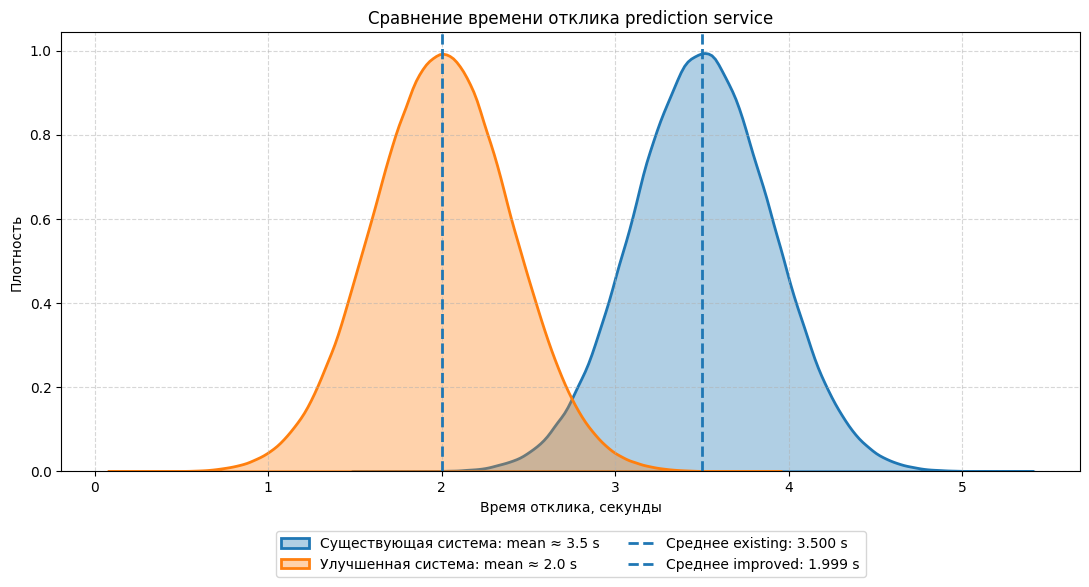

In [4]:
import seaborn as sns

plt.figure(figsize=(11, 6))

sns.kdeplot(
    existing_system_responses,
    label="Существующая система: mean ≈ 3.5 s",
    fill=True,
    alpha=0.35,
    linewidth=2,
)

sns.kdeplot(
    improved_system_responses,
    label="Улучшенная система: mean ≈ 2.0 s",
    fill=True,
    alpha=0.35,
    linewidth=2,
)

existing_mean = np.mean(existing_system_responses)
improved_mean = np.mean(improved_system_responses)

plt.axvline(
    existing_mean,
    linestyle="--",
    linewidth=2,
    label=f"Среднее existing: {existing_mean:.3f} s",
)

plt.axvline(
    improved_mean,
    linestyle="--",
    linewidth=2,
    label=f"Среднее improved: {improved_mean:.3f} s",
)

plt.title("Сравнение времени отклика prediction service")
plt.xlabel("Время отклика, секунды")
plt.ylabel("Плотность")
plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True,
)

plt.tight_layout()
plt.show()

## 5. Постановка A/B-теста

Сравниваем две независимые группы latency:

```text
A = existing system
B = improved system
```

Метрика:

```text
latency, seconds
```

Так как для latency меньшее значение лучше, проверяем стала ли улучшенная система статистически значимо быстрее.

### Нулевая гипотеза

```text
H0: μ_B >= μ_A
```

Среднее время отклика улучшенной системы не меньше среднего времени отклика существующей системы.  
То есть, новая система не быстрее.

### Альтернативная гипотеза

```text
H1: μ_B < μ_A
```

Среднее время отклика улучшенной системы меньше среднего времени отклика существующей системы.  
Иными словами, новая система быстрее.

### Уровень значимости

```text
alpha = 0.05
```

### Статистический тест

Используем **двухвыборочный Welch's t-test** в односторонней постановке.

Почему именно он:

- сравниваются две независимые выборки;
- не требуется предполагать равенство дисперсий;
- гипотеза направленная: нас интересует именно уменьшение latency у улучшенной системы.


In [5]:
alpha = 0.05

test_result = stats.ttest_ind(
    improved_system_responses,
    existing_system_responses,
    equal_var=False,
    alternative="less",
)

t_statistic = test_result.statistic
p_value = test_result.pvalue

print(f"t-статистика = {t_statistic:.6f}")
print(f"p-value      = {p_value:.10e}")
print(f"alpha        = {alpha}")

if p_value < alpha:
    print("Решение: отклоняем H0.")
    print(
        "Вывод: улучшенная система имеет статистически значимо меньшее "
        "среднее время отклика."
    )
else:
    print("Решение: нет оснований отклонить H0.")
    print(
        "Вывод: недостаточно статистических оснований считать, "
        "что улучшенная система быстрее."
    )

t-статистика = -1875.079284
p-value      = 0.0000000000e+00
alpha        = 0.05
Решение: отклоняем H0.
Вывод: улучшенная система имеет статистически значимо меньшее среднее время отклика.


## 6. Практический эффект

Одного p-value недостаточно: при большой выборке даже небольшие отличия могут стать статистически значимыми.

Поэтому дополнительно еще посчитаем практический эффект:

- абсолютное снижение среднего latency;
- относительное снижение среднего latency;
- абсолютное и относительное снижение p95 latency.


In [6]:
mean_existing = float(np.mean(existing_system_responses))
mean_improved = float(np.mean(improved_system_responses))

p95_existing = float(np.percentile(existing_system_responses, 95))
p95_improved = float(np.percentile(improved_system_responses, 95))

absolute_mean_improvement = mean_existing - mean_improved
relative_mean_improvement = absolute_mean_improvement / mean_existing

absolute_p95_improvement = p95_existing - p95_improved
relative_p95_improvement = absolute_p95_improvement / p95_existing

effect_summary = pd.DataFrame(
    {
        "metric": ["mean_latency", "p95_latency"],
        "existing_system": [mean_existing, p95_existing],
        "improved_system": [mean_improved, p95_improved],
        "absolute_improvement_seconds": [
            absolute_mean_improvement,
            absolute_p95_improvement,
        ],
        "relative_improvement": [
            relative_mean_improvement,
            relative_p95_improvement,
        ],
    }
)

effect_summary


,metric,existing_system,improved_system,absolute_improvement_seconds,relative_improvement
0,mean_latency,3.499534,1.999187,1.500347,0.428728
1,p95_latency,4.157449,2.656529,1.500919,0.361019


In [7]:
print(f"Среднее время отклика существующей системы: {mean_existing:.4f} секунды")
print(f"Среднее время отклика улучшенной системы: {mean_improved:.4f} секунды")
print(f"Абсолютное снижение среднего времени отклика: {absolute_mean_improvement:.4f} секунды")
print(f"Относительное снижение среднего времени отклика: {relative_mean_improvement:.2%}")

print()

print(f"p95 latency существующей системы: {p95_existing:.4f} секунды")
print(f"p95 latency улучшенной системы: {p95_improved:.4f} секунды")
print(f"Абсолютное снижение p95 latency: {absolute_p95_improvement:.4f} секунды")
print(f"Относительное снижение p95 latency: {relative_p95_improvement:.2%}")

Среднее время отклика существующей системы: 3.4995 секунды
Среднее время отклика улучшенной системы: 1.9992 секунды
Абсолютное снижение среднего времени отклика: 1.5003 секунды
Относительное снижение среднего времени отклика: 42.87%

p95 latency существующей системы: 4.1574 секунды
p95 latency улучшенной системы: 2.6565 секунды
Абсолютное снижение p95 latency: 1.5009 секунды
Относительное снижение p95 latency: 36.10%


## 7. Архитектурное решение по MDD

По результатам A/B-анализа latency-метрик из условия шага 5:

- p-value меньше `alpha = 0.05`;
- нулевая гипотеза `H0: μ_B >= μ_A` отклоняется;
- есть статистически значимые основания считать, что improved system имеет меньшее среднее latency, чем existing system;
- практический эффект тоже существенный среднее latency и p95 latency заметно ниже.

Следовательно, в рамках MDD принимается решение в пользу улучшенной serving-архитектуры.

В этом проекте это решение соответствует ADR-0003 и выражается так:

- модель обслуживается отдельным FastAPI inference service;
- endpoint `/predict` выполняет инференс по признакам, переданным напрямую в request body;
- endpoint `/predict/from-feature-store` выполняет production-like inference: принимает `machine_id`, получает online-признаки из Feast Redis Online Store и затем применяет production-модель из MLflow Model Registry;
- production-модель в базовом режиме загружается из MLflow Model Registry по alias `champion`;
- `champion` отвечает за выбор production-версии модели, а `stable` и `canary` отвечают за deployment track API-сервиса;
- canary gateway позволяет постепенно переключать трафик между stable и canary inference service;
- Prometheus собирает latency, request count, error rate и метрики online feature retrieval;
- Grafana визуализирует технические SLI;
- p95 latency включается в SLO и quality gate;
- успешность online feature retrieval включается в SLO и Prometheus alert rules.

## 8. Связь с Prometheus/SLO

В проекте latency и ошибки сервиса наблюдаются через Prometheus.

Основные метрики prediction service:

```text
predict_requests_total
predict_errors_total
predict_latency_seconds
prediction_risk_level_total
```

Метрики online feature retrieval из Feast Redis:

```text
feature_retrieval_requests_total
feature_retrieval_errors_total
feature_retrieval_latency_seconds
```

Prometheus alert rule:

```text
PredictiveMaintenanceFeatureRetrievalErrors
```

срабатывает, если error rate online feature retrieval превышает допустимый уровень.

Таким образом, принятое MDD-решение связано не только с разовым A/B-тестом, но и с дальнейшим production-мониторингом latency, error rate и feature retrieval.

**Фактические latency уже реализованного сервиса в дальнейшем должны оцениваться Prometheus-метриками `predict_latency_seconds` и `feature_retrieval_latency_seconds`.**


## 9. Связь с ADR

Этот ноутбук является расчётным приложением к ADR:

```text
docs/adr/0003-latency-driven-serving-decision.md
```

В ADR фиксируются:

- два набора latency-метрик;
- гипотезы `H0` и `H1`;
- уровень значимости `alpha = 0.05`;
- выбранный статистический тест;
- результат по p-value;
- итоговое архитектурное решение.

Итоговая формулировка:

```text
На основании A/B-анализа latency-метрик, предоставленных в условии задания,
и Welch's t-test в односторонней постановке нулевая гипотеза о том, что
улучшенная система не быстрее существующей, отклоняется при alpha = 0.05.

Поэтому в рамках MDD принимается архитектурное решение в пользу улучшенной
serving-архитектуры. 

В проекте это решение реализуется через отдельный FastAPI inference service, production-like endpoint /predict/from-feature-store с online feature retrieval из Feast Redis Online Store, загрузку production-модели из MLflow Model Registry по alias champion, Prometheus/Grafana monitoring, SLO as Code и Prometheus alert rules для latency и feature retrieval, а также Nginx-based canary traffic switching между stable и canary API-сервисами.
```
